In [146]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [147]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px

pd.set_option('display.max_columns', None)

In [148]:
history=pd.read_csv('/content/drive/MyDrive/AirLens/Datasets/Customer Loyalty History.csv')
flight = pd.read_csv('/content/drive/MyDrive/AirLens/Datasets/Customer Flight Activity.csv')
calendar = pd.read_csv('/content/drive/MyDrive/AirLens/Datasets/Calendar.csv')

In [149]:

history.isnull().sum()

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,4238
Marital Status,0
Loyalty Card,0


In [150]:
history.duplicated().sum()

np.int64(0)

In [151]:
flight.isnull().sum()

,0
Loyalty Number,0
Year,0
Month,0
Total Flights,0
Distance,0
Points Accumulated,0
Points Redeemed,0
Dollar Cost Points Redeemed,0


In [152]:
flight.duplicated().sum()

np.int64(1922)

In [153]:
calendar.isnull().sum()


,0
Date,0
Start of Year,0
Start of Quarter,0
Start of Month,0


In [154]:
calendar.duplicated().sum()

np.int64(0)

In [155]:
history.describe()

,Loyalty Number,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
count,16737.000000,12499.000000,16737.000000,16737.000000,16737.000000,2067.000000,2067.000000
mean,549735.880445,79245.609409,7988.896536,2015.253211,6.669116,2016.503145,6.962748
std,258912.132453,35008.297285,6860.982280,1.979111,3.398958,1.380743,3.455297
min,100018.000000,-58486.000000,1898.010000,2012.000000,1.000000,2013.000000,1.000000
25%,326603.000000,59246.500000,3980.840000,2014.000000,4.000000,2016.000000,4.000000
50%,550434.000000,73455.000000,5780.180000,2015.000000,7.000000,2017.000000,7.000000
75%,772019.000000,88517.500000,8940.580000,2017.000000,10.000000,2018.000000,10.000000
max,999986.000000,407228.000000,83325.380000,2018.000000,12.000000,2018.000000,12.000000


In [156]:
flight.describe()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000
mean,550527.519034,2017.513661,6.513661,1.294888,1941.440201,2027.172345,31.304263,5.635661
std,258604.580187,0.499814,3.445428,1.962675,3239.975889,3872.139841,126.653775,22.801167
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,327688.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,551833.000000,2018.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,772194.000000,2018.000000,10.000000,2.000000,3018.000000,3039.000000,0.000000,0.000000
max,999986.000000,2018.000000,12.000000,28.000000,67284.000000,100926.000000,876.000000,158.000000


In [157]:
calendar.describe()

,Date,Start of Year,Start of Quarter,Start of Month
count,2557,2557,2557,2557
unique,2557,7,28,84
top,2018-12-31,2012-01-01,2012-10-01,2012-01-01
freq,1,366,92,31


In [158]:
calendar.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2557 non-null   object
 1   Start of Year     2557 non-null   object
 2   Start of Quarter  2557 non-null   object
 3   Start of Month    2557 non-null   object
dtypes: object(4)
memory usage: 80.0+ KB


In [159]:
history_clean = history.copy()

flight_clean = flight.copy()

calendar_clean = calendar.copy()

In [160]:
print("History duplicates:", history_clean.duplicated().sum())

print("Flight duplicates:", flight_clean.duplicated().sum())

print("Calendar duplicates:", calendar_clean.duplicated().sum())

History duplicates: 0
Flight duplicates: 1922
Calendar duplicates: 0


In [161]:
history_clean[history_clean["Salary"] < 0]

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.0,Divorced,Star,24127.50,2018 Promotion,2018,3,NaN,NaN
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.0,Married,Aurora,9453.00,2018 Promotion,2018,3,NaN,NaN
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,3,NaN,NaN
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.0,Married,Star,2402.33,2018 Promotion,2018,3,NaN,NaN
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.0,Single,Star,2893.74,2018 Promotion,2018,3,NaN,NaN
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234.0,Married,Star,7597.91,2018 Promotion,2018,3,NaN,NaN
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.0,Married,Nova,5860.17,2018 Promotion,2018,4,NaN,NaN
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.0,Married,Nova,49423.80,2018 Promotion,2018,3,NaN,NaN
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.0,Married,Aurora,5067.21,2018 Promotion,2018,2,NaN,NaN
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.0,Married,Nova,2888.85,2018 Promotion,2018,2,NaN,NaN


## Data Quality Findings

1. Customer Loyalty History contains no duplicate records.

2. Flight Activity contains 1,922 duplicate records, which will be investigated before removal.

3. Salary has 4,238 missing values (about 25%).

4. 20 customers have negative salary values. Since negative salaries are not realistic and are concentrated among customers enrolled through the 2018 Promotion, these values will be treated as invalid and replaced with missing values before imputation.

5. Missing cancellation dates are expected because they represent customers who have not cancelled their loyalty membership.

In [162]:
#Removing Duplicates

In [163]:
(history_clean["Salary"] < 0).sum()
history_clean.loc[history_clean["Salary"] < 0, "Salary"] = np.nan
(history_clean["Salary"] < 0).sum()

np.int64(0)

In [164]:
history_clean["Salary"].isnull().sum()

np.int64(4258)

In [165]:
duplicate_rows = flight_clean[flight_clean.duplicated()]
duplicate_rows.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
176809,357901,2018,2,0,0,0.0,0,0
176811,357901,2018,3,0,0,0.0,0,0
176813,357901,2018,4,0,0,0.0,0,0
176819,357901,2018,9,0,0,0.0,0,0
176822,357901,2018,11,0,0,0.0,0,0


In [166]:
duplicate_rows.sample(10)

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
349866,833793,2018,10,0,0,0.0,0,0
209345,403529,2017,4,0,0,0.0,0,0
231528,750578,2017,6,0,0,0.0,0,0
205645,950980,2017,3,0,0,0.0,0,0
342349,577232,2018,7,0,0,0.0,0,0
193771,719633,2017,2,0,0,0.0,0,0
227914,402697,2017,6,0,0,0.0,0,0
340885,407404,2018,7,0,0,0.0,0,0
232510,849813,2017,6,0,0,0.0,0,0
329312,927026,2018,5,0,0,0.0,0,0


In [167]:
flight_clean.iloc[duplicate_rows.index[0]]

,176809
Loyalty Number,357901.0
Year,2018.0
Month,2.0
Total Flights,0.0
Distance,0.0
Points Accumulated,0.0
Points Redeemed,0.0
Dollar Cost Points Redeemed,0.0


In [168]:
flight_clean.iloc[duplicate_rows.index[0]-1]

,176808
Loyalty Number,357901.0
Year,2018.0
Month,2.0
Total Flights,0.0
Distance,0.0
Points Accumulated,0.0
Points Redeemed,0.0
Dollar Cost Points Redeemed,0.0


In [169]:
flight_clean = flight_clean.drop_duplicates()

In [170]:
flight_clean.duplicated().sum()
flight_clean.shape


(391014, 8)

## Data Cleaning Log

### Customer Loyalty History

- No duplicate records found.
- Salary contains 4,238 missing values.
- Twenty customers had negative salaries. These were treated as invalid values and replaced with NaN.
- Missing cancellation dates indicate active customers and were retained.

### Customer Flight Activity

- Found 1,922 duplicate records.
- Verified that these were exact duplicate rows.
- Removed duplicate records using `drop_duplicates()`.

### Calendar

- No duplicate records found.
- Date columns will be converted to datetime format in a later step.

In [171]:
salary_mean = history_clean["Salary"].mean()
salary_median = history_clean["Salary"].median()

print("Mean Salary :", salary_mean)
print("Median Salary:", salary_median)

Mean Salary : 79429.57264203862
Median Salary: 73510.0


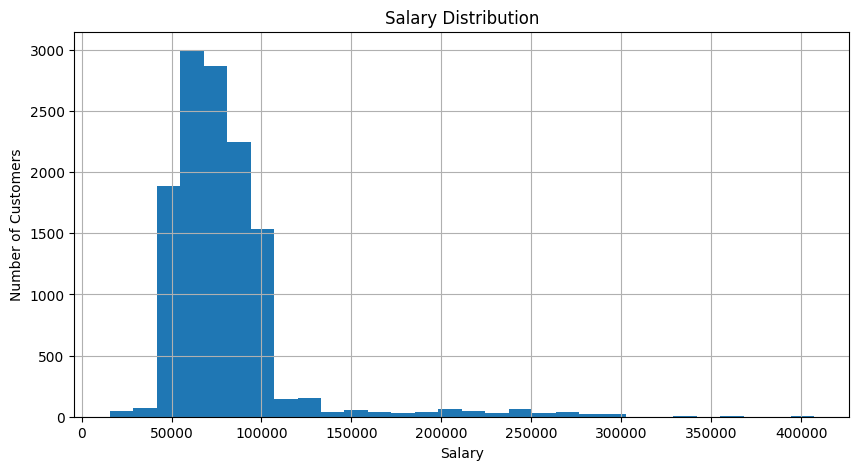

In [172]:
plt.figure(figsize=(10,5))

history_clean["Salary"].hist(bins=30)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Customers")

plt.show()

In [173]:
history_clean["Salary"].isnull().sum()

np.int64(4258)

In [174]:
history_clean["Salary"].isnull().mean() * 100

np.float64(25.44064049710223)

In [175]:
history_clean["Salary"] = history_clean["Salary"].fillna(salary_median)

In [176]:
history_clean.isnull().sum()

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,0
Marital Status,0
Loyalty Card,0


In [177]:
calendar_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2557 non-null   object
 1   Start of Year     2557 non-null   object
 2   Start of Quarter  2557 non-null   object
 3   Start of Month    2557 non-null   object
dtypes: object(4)
memory usage: 80.0+ KB


In [178]:
calendar_clean["Date"] = pd.to_datetime(calendar_clean["Date"])
calendar_clean["Start of Year"] = pd.to_datetime(calendar_clean["Start of Year"])
calendar_clean["Start of Quarter"] = pd.to_datetime(calendar_clean["Start of Quarter"])
calendar_clean["Start of Month"] = pd.to_datetime(calendar_clean["Start of Month"])

In [179]:
calendar_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2557 non-null   datetime64[ns]
 1   Start of Year     2557 non-null   datetime64[ns]
 2   Start of Quarter  2557 non-null   datetime64[ns]
 3   Start of Month    2557 non-null   datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 80.0 KB


# Data Cleaning Summary

## Customer Loyalty History
- No duplicate records found.
- Replaced 20 negative salary values with NaN.
- Filled missing salary values using the median salary because the distribution was right-skewed.
- Missing cancellation year/month values were retained because they indicate active customers.

## Customer Flight Activity
- Identified 1,922 exact duplicate records.
- Removed duplicate rows.

## Calendar
- Converted date columns from object to datetime.

-----------------------------------------------------------
1) How many customers belong to each Loyalty Card?

In [180]:
loyalty_counts=history_clean["Loyalty Card"].value_counts()
print(loyalty_counts)
loyalty_counts/sum(loyalty_counts)*100

Loyalty Card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64


,count
Loyalty Card,
Star,45.629444
Nova,33.883014
Aurora,20.487543


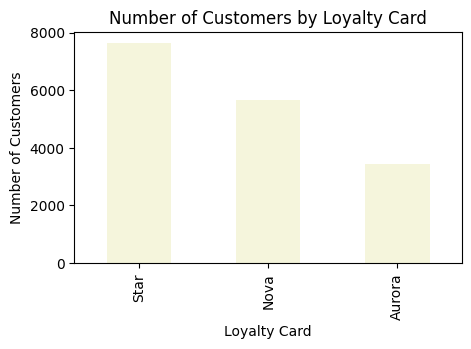

In [181]:
plt.figure(figsize=(5,3))

loyalty_counts.plot(kind="bar",color='beige')

plt.title("Number of Customers by Loyalty Card")

plt.xlabel("Loyalty Card")

plt.ylabel("Number of Customers")

plt.show()

##Business Question 1
### How many customers belong to each Loyalty Card?
### Business Insight

- The Star loyalty card has the largest customer base (7,637 members), followed by Nova (5,671) and Aurora (3,429).
- This indicates that Star members account for the majority of the airline's loyalty customers.
- Large-scale promotional campaigns will reach the highest number of customers if targeted at Star members.
- However, customer count alone does not indicate business value. Further analysis of Customer Lifetime Value (CLV) is required to determine which loyalty tier contributes the most revenue.

-------------------------------------------------
2) Which loyalty card has the highest average CLV?

In [182]:
clv_by_card=history_clean.groupby("Loyalty Card")["CLV"].mean()
clv_by_card

,CLV
Loyalty Card,
Aurora,10672.686325
Nova,8045.615995
Star,6741.761372


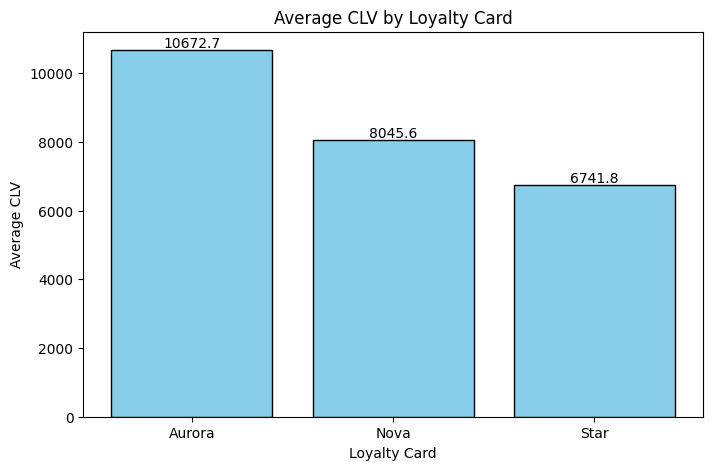

In [183]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    clv_by_card.index,
    clv_by_card.values,
    color="skyblue",
    edgecolor="black"
)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),1),
        ha="center",
        va="bottom"
    )

plt.title("Average CLV by Loyalty Card")
plt.xlabel("Loyalty Card")
plt.ylabel("Average CLV")
plt.show()

##Business Question 2
### Which loyalty card has the highest average CLV?
###Business Insight
*    Aurora customers have the highest average CLV.
*   Star customers have the largest customer base but the lowest average CLV.
*   The airline should pay special attention to retaining Aurora customers because each customer is more valuable.





----------------------------------------
3) How customers are distributed across Gender?

In [184]:
Gender_counts=history_clean["Gender"].value_counts()

In [185]:
Gender_counts/sum(history_clean["Gender"].value_counts())*100

,count
Gender,
Female,50.247954
Male,49.752046


In [186]:
history_clean.groupby("Gender")["CLV"].mean()

,CLV
Gender,
Female,7982.474039
Male,7995.383049


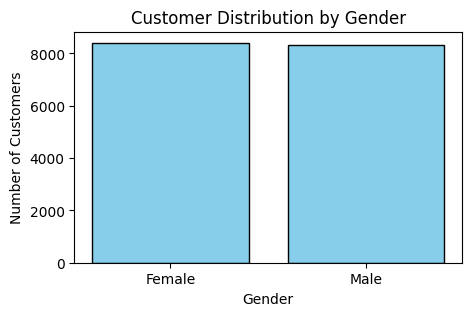

In [187]:
plt.figure(figsize=(5,3))
bars = plt.bar(
    Gender_counts.index,
    Gender_counts.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()



# Business Question 3
### How are customers distributed by Gender?
### Business Insight

- Female customers account for approximately 50.25% of the loyalty members, while male customers account for 49.75%.
- The customer base is almost evenly distributed across genders.
- This suggests that the airline's loyalty program appeals equally to both male and female customers.
- Marketing campaigns can be designed for a broad audience without focusing heavily on one gender.

-----------------------------------------------------
4) What is the distribution of customers across different Education levels?

In [188]:
education_counts = history_clean["Education"].value_counts()

print(education_counts)

Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64


In [189]:
education_counts/sum(education_counts)*100

,count
Education,
Bachelor,62.585888
College,25.321145
High School or Below,4.672283
Doctor,4.385493
Master,3.035191


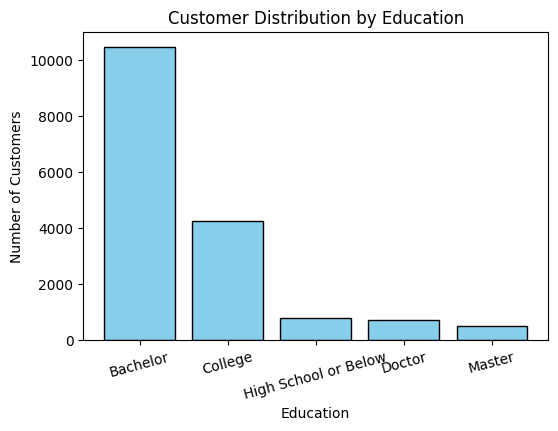

In [190]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    education_counts.index,
    education_counts.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Customer Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

## Business Question 4
### How are customers distributed across education levels?
### Business Insight

- Most loyalty members hold a Bachelor's degree, followed by College education.
- Customers with Master's and Doctoral degrees form a relatively small portion of the customer base.
- Education distribution provides useful demographic information, but further analysis is needed to determine whether education influences customer value or loyalty.

In [191]:

education_clv=history_clean.groupby("Education")["CLV"].mean()
education_clv

,CLV
Education,
Bachelor,8206.990833
College,7594.571756
Doctor,7832.919523
High School or Below,7707.080384
Master,7440.624902


## Business Question
### Does education influence Customer Lifetime Value (CLV)?
### Business Insight

- Customers with a Bachelor's degree have the highest average CLV (≈ 8,207).
- The difference in CLV across education levels is relatively small.
- Education alone does not appear to strongly differentiate customer value.
- Behavioral features such as flight frequency and loyalty activity are likely to provide better insights for customer segmentation.

----------------------------------------------
5) Which provinces have the highest number of loyalty members?

In [192]:
province_counts = history_clean["Province"].value_counts()
province_counts.head(10)

,count
Province,
Ontario,5404
British Columbia,4409
Quebec,3300
Alberta,969
Manitoba,658
New Brunswick,636
Nova Scotia,518
Saskatchewan,409
Newfoundland,258


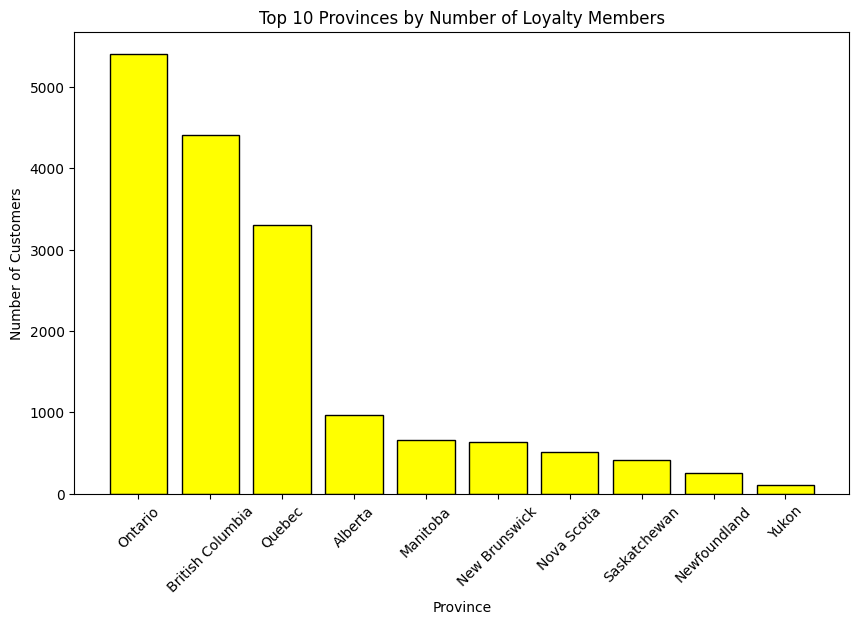

In [193]:
province_top10 = history_clean["Province"].value_counts().head(10)
plt.figure(figsize=(10,6))
bars = plt.bar(
    province_top10.index,
    province_top10.values,
    color="yellow",
    edgecolor="black"
)
plt.title("Top 10 Provinces by Number of Loyalty Members")
plt.xlabel("Province")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

## Business Question 5
### Which provinces have the highest number of loyalty members?
### Business Insight

- Ontario has the highest number of loyalty members (5,404), followed by British Columbia and Quebec.
- These three provinces represent the airline's largest customer markets.
- Marketing campaigns should primarily focus on these provinces to maximize customer reach.
- Provinces with smaller customer bases, such as Yukon and Newfoundland, may benefit from targeted and personalized marketing strategies instead of large-scale campaigns.

---------------------------------------------------
6) Which provinces generate the highest average Customer Lifetime Value?

In [194]:
province_clv=history_clean.groupby('Province')['CLV'].mean().sort_values(ascending=True)
province_clv.sort_values(ascending=False)

,CLV
Province,
Quebec,8160.956282
New Brunswick,8154.182673
Saskatchewan,8076.374499
Manitoba,8066.555775
Newfoundland,8025.080349
British Columbia,7993.727410
Nova Scotia,7983.304749
Ontario,7913.752258
Alberta,7752.788658


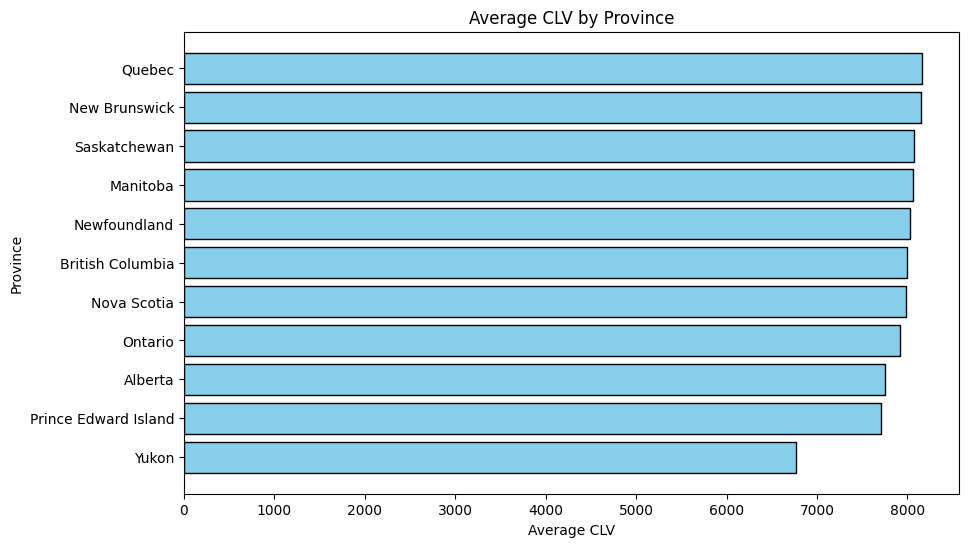

In [195]:

plt.figure(figsize=(10,6))
bars = plt.barh(
    province_clv.index,
    province_clv.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Average CLV by Province")
plt.xlabel("Average CLV")
plt.ylabel("Province")
plt.show()

## Business Question 6
### Which provinces generate the highest average Customer Lifetime Value?
### Business Insight
- Quebec has the highest average CLV despite having fewer customers than Ontario.
- Ontario has the largest customer base, making it an important market for customer acquisition and engagement.
- Customer count and customer value are different metrics and should be analyzed together before making marketing decisions.
- High-value provinces should receive stronger retention efforts, while high-volume provinces should focus on both acquisition and retention.

-------------------------------------------------
7) Which months have the highest number of flights?

In [196]:
monthly_flights = flight_clean.groupby("Month")["Total Flights"].sum()
monthly_flights

,Total Flights
Month,
1,26384
2,26908
3,38048
4,31284
5,46035
6,57344
7,64248
8,55784
9,39473


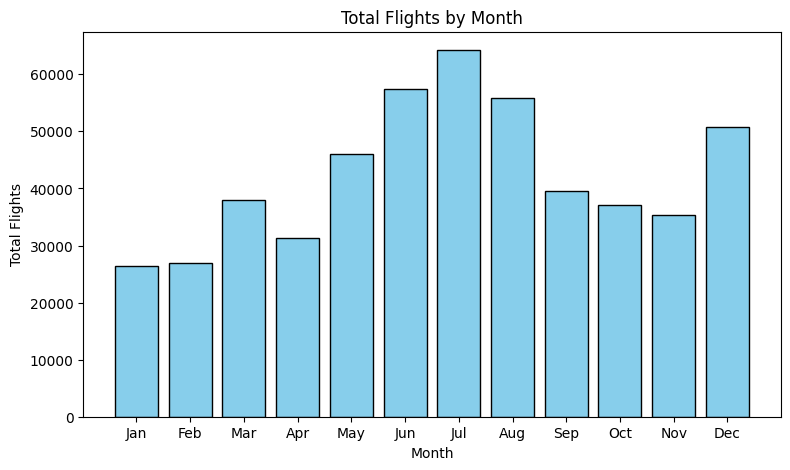

In [197]:
plt.figure(figsize=(9,5))
bars = plt.bar(
    monthly_flights.index,
    monthly_flights.values,
    color="skyblue",
    edgecolor="black"
)
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]
plt.xticks(range(1,13), months)
plt.title("Total Flights by Month")
plt.xlabel("Month")
plt.ylabel("Total Flights")
plt.show()

## Business Question 7
### Which months have the highest number of flights?
### Business Insight

- July recorded the highest number of flights (64,248), indicating peak travel demand.
- Flight activity gradually increases from March and remains high through August, suggesting seasonal travel patterns.
- January and February have the lowest flight activity, making them suitable months for promotional campaigns to stimulate demand.
- December also experiences high travel demand, likely due to holiday travel.

--------------------------------------------------
8) How much total distance was traveled each month?

In [198]:
monthly_dist=flight_clean.groupby('Month')['Distance'].sum().sort_values(ascending=False)
monthly_dist

,Distance
Month,
7,96590333
6,85954396
8,83529205
12,76074382
5,68715163
9,59397858
3,57106726
10,55512426
11,53165387


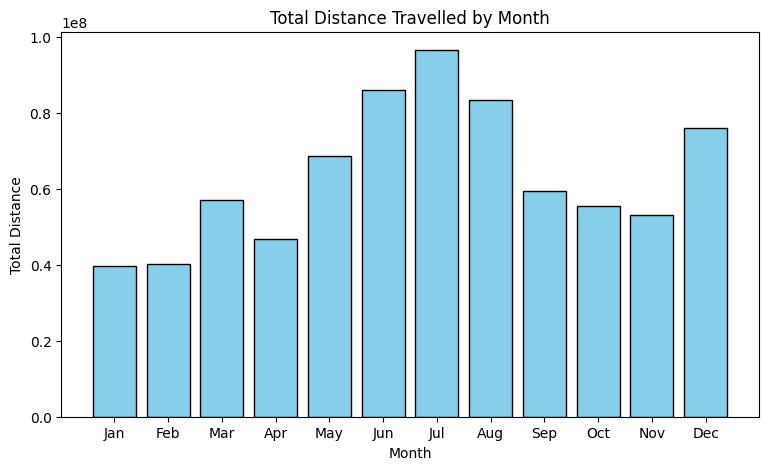

In [199]:
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9,5))

bars = plt.bar(
    monthly_dist.index,
    monthly_dist.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Total Distance Travelled by Month")
plt.xlabel("Month")
plt.ylabel("Total Distance")
plt.xticks(range(1,13), months)
plt.show()

## Business Question 8
### Which months have the highest total distance travelled?
### Business Insight

- July recorded the highest total travel distance, followed by June and August.
- The months with the highest travel distance are also the months with the highest number of flights, indicating strong seasonal demand.
- January and February recorded the lowest travel distances, suggesting lower customer activity during these months.
- The airline should increase operational capacity during peak months and consider promotional campaigns during low-demand periods.

------------------------------------------------------
9) How many loyalty points are accumulated each month?

In [200]:
monthly_points=flight_clean.groupby('Month')['Points Accumulated'].sum().sort_values(ascending=False)
monthly_points

,Points Accumulated
Month,
7,103011849.0
6,91913574.0
8,89137865.0
12,79735285.0
5,73337483.0
9,61472270.0
3,57767875.5
10,57504428.0
11,54860217.0


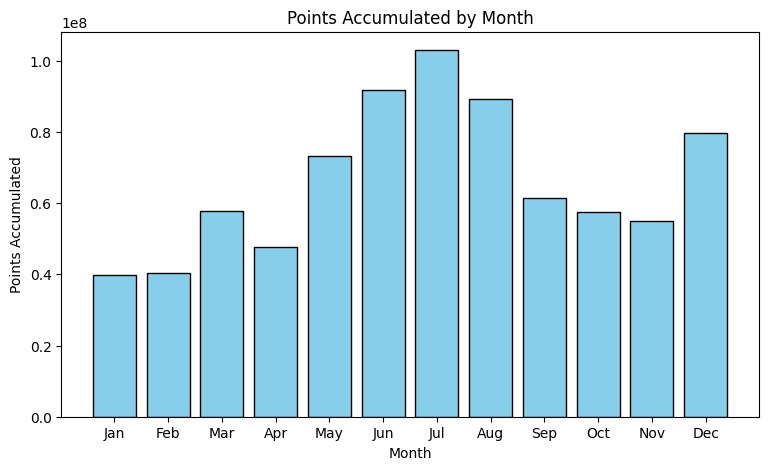

In [201]:
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(9,5))
bars = plt.bar(
    monthly_points.index,
    monthly_points.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Points Accumulated by Month")
plt.xlabel("Month")
plt.ylabel("Points Accumulated")

plt.xticks(range(1,13), months)
plt.show()

## Business Question 9
### Which months have the highest loyalty points accumulated?
### Business Insight

- July recorded the highest loyalty points accumulated, followed by June and August.
- The monthly trend closely matches the trends observed for total flights and total distance travelled.
- This indicates that customer engagement is highest during the summer months and year-end holiday season.
- The airline should leverage these peak periods for premium loyalty campaigns while using bonus point promotions during off-peak months to increase customer activity.

---------------------------------------------
10)How many loyalty points are redeemed each month?

In [202]:
monthly_redeemed=flight_clean.groupby('Month')['Points Redeemed'].sum().sort_values(ascending=False)
monthly_redeemed

,Points Redeemed
Month,
7,1285486
6,1242296
8,1200588
12,1199156
5,1026724
9,1024397
3,980814
10,961343
11,911051


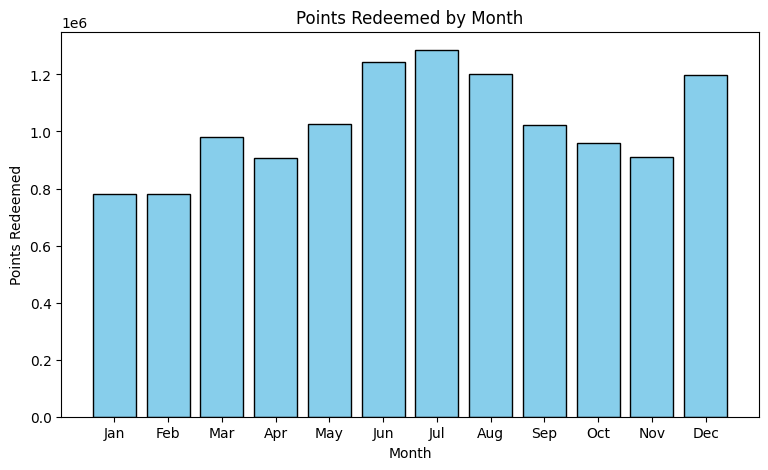

In [203]:
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(9,5))
bars = plt.bar(
    monthly_redeemed.index,
    monthly_redeemed.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Points Redeemed by Month")
plt.xlabel("Month")
plt.ylabel("Points Redeemed")

plt.xticks(range(1,13), months)
plt.show()

## Business Question 10
### Which months have the highest loyalty points redeemed?
### Business Insight

- July recorded the highest number of redeemed loyalty points, followed by June and August.
- The redemption trend closely matches flight activity and points accumulation, indicating strong customer engagement during peak travel seasons.
- January and February have the lowest redemption activity, making them suitable months for promotional redemption campaigns.
- The airline can improve off-peak engagement by introducing bonus redemption offers during low-demand periods.

------------------------------------------------
11) Who are the Top 10 Most Frequent Flyers?

In [204]:
customer_flights = flight_clean.groupby("Loyalty Number")["Total Flights"].sum().sort_values(ascending=False)
customer_flights.head(10)

,Total Flights
Loyalty Number,
336882,106
813455,104
385092,102
983416,100
732304,98
110065,97
625320,96
464187,96
556492,95


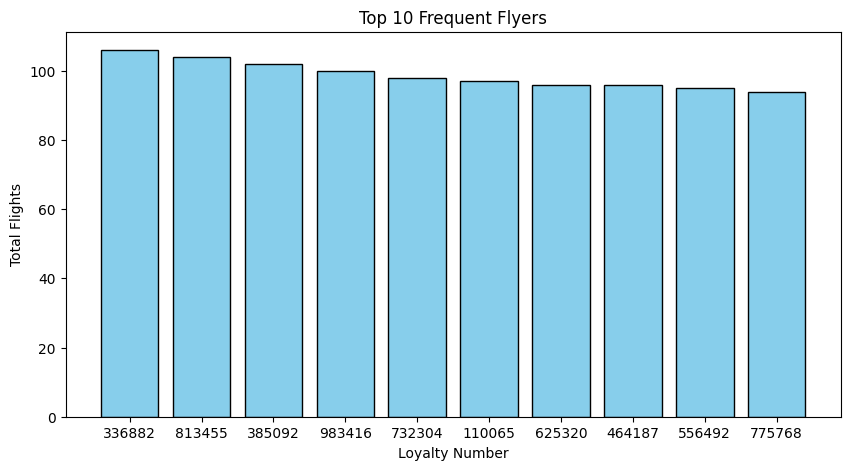

In [205]:
top10 = customer_flights.head(10)
plt.figure(figsize=(10,5))

bars = plt.bar(
    top10.index.astype(str),
    top10.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Top 10 Frequent Flyers")
plt.xlabel("Loyalty Number")
plt.ylabel("Total Flights")
plt.show()

## Business Question 11
### Who are the Top 10 Most Frequent Flyers?
### Business Insight

- The top frequent flyer completed 106 flights during the analysis period.
- All top 10 customers completed more than 90 flights, indicating very high engagement with the airline.
- These customers are likely to contribute significantly to long-term revenue and customer lifetime value.
- The airline should prioritize these customers through premium loyalty benefits, personalized services, and exclusive rewards to maximize retention.

-----------------------------------------------
12) How many unique customers were active each month?

In [206]:

monthly_active = flight_clean.groupby("Month")["Loyalty Number"].nunique()
print(monthly_active)

Month
1     15766
2     16737
3     16737
4     16737
5     16737
6     16737
7     16737
8     16737
9     16737
10    16737
11    16737
12    16737
Name: Loyalty Number, dtype: int64


In [207]:
flight_clean[flight_clean["Loyalty Number"] == 100018]

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
19954,100018,2018,12,5,12060,12060.0,0,0
32361,100018,2017,11,4,2028,2028.0,0,0
34905,100018,2017,3,4,9648,9648.0,438,79
42688,100018,2018,9,4,8932,8932.0,0,0
58535,100018,2017,7,3,3687,3687.0,0,0
61461,100018,2017,9,3,5751,5751.0,0,0
62197,100018,2017,8,3,7116,7116.0,690,124
79087,100018,2018,7,3,3972,3972.0,0,0
86080,100018,2018,11,3,6693,6693.0,0,0
95619,100018,2018,10,2,4720,4720.0,385,69


In [208]:
active_flights = flight_clean[flight_clean["Total Flights"] > 0]
monthly_active = active_flights.groupby("Month")["Loyalty Number"].nunique()

monthly_active

,Loyalty Number
Month,
1,9790
2,10137
3,10692
4,10405
5,10905
6,11017
7,11576
8,11289
9,11010


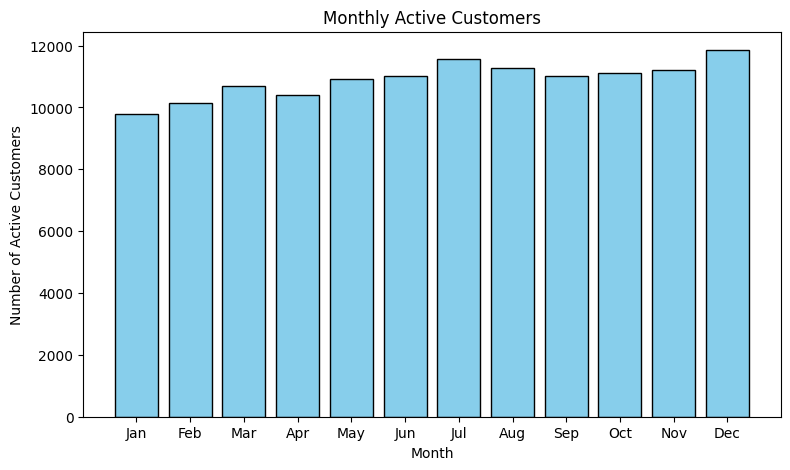

In [209]:
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9,5))

bars = plt.bar(
    monthly_active.index,
    monthly_active.values,
    color="skyblue",
    edgecolor="black"
)
plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Number of Active Customers")

plt.xticks(range(1,13), months)
plt.show()

## Business Question 12
### How many customers were active each month?
### Business Insight

- December recorded the highest number of active customers (11,855), indicating the widest customer participation during the year.
- July recorded the highest total flights but not the highest number of active customers, suggesting that customers flew more frequently during July.
- January had the lowest number of active customers, making it a suitable month for re-engagement campaigns.
- The difference between active customers and total flights highlights the importance of analyzing multiple metrics to understand customer behavior.

-------------------------------------------------------------
13) Do customers who fly more also earn more loyalty points?

In [210]:
customer_behavior = flight_clean.groupby("Loyalty Number").agg({
    "Total Flights":"sum",
    "Points Accumulated":"sum"
})

customer_behavior.head()

,Total Flights,Points Accumulated
Loyalty Number,,
100018,46,81190.0
100102,51,68918.0
100140,47,72856.0
100214,22,38236.0
100272,37,54997.0


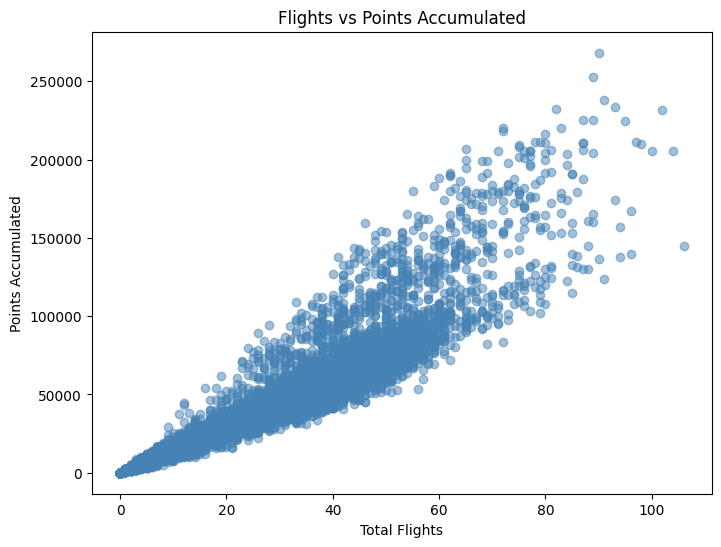

In [211]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_behavior["Total Flights"],
    customer_behavior["Points Accumulated"],
    alpha=0.5,
    color="steelblue"
)

plt.title("Flights vs Points Accumulated")
plt.xlabel("Total Flights")
plt.ylabel("Points Accumulated")
plt.show()

In [212]:
customer_behavior["Total Flights"].corr(
    customer_behavior["Points Accumulated"]
)

np.float64(0.9285460514875041)

## Business Question 13
### Do customers who fly more also earn more loyalty points?
### Business Insight

- The correlation between total flights and accumulated loyalty points is **0.93**, indicating a very strong positive relationship.
- Customers who fly more generally earn significantly more loyalty points.
- This confirms that the airline's loyalty program effectively rewards increased travel activity.
- Flight frequency is expected to be an important predictor for customer value and churn in later modeling stages.

In [215]:
history_clean.head()
history_clean.to_csv("history_clean.csv", index=False)

flight_clean.to_csv("flight_clean.csv", index=False)

calendar.to_csv("calendar_clean.csv", index=False)

In [216]:
import os

os.listdir()

['.config',
 'history_clean.csv',
 'flight_clean.csv',
 'drive',
 'calendar_clean.csv',
 'sample_data']

In [218]:
from google.colab import files

files.download("history_clean.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>